In [2]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [3]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import os
import shap
from bertopic import BERTopic
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [6]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
train_df = pd.read_csv('../data/combined_letters_degendered_with_topics_train_granular.csv')
val_df = pd.read_csv('../data/combined_letters_degendered_with_topics_val_granular.csv')
test_df = pd.read_csv('../data/combined_letters_degendered_with_topics_test_granular.csv')

In [7]:
train_df = train_df.drop('full_text', axis=1)
val_df = val_df.drop('full_text', axis=1)
test_df = test_df.drop('full_text', axis=1)

# Create Train and Test Set

In [8]:
topic_cols = [col for col in train_df.columns if col != 'label']

In [9]:
X_train = train_df[topic_cols]
y_train = train_df['label']

In [10]:
X_val = val_df[topic_cols]
y_val = val_df['label']

X_eval = test_df[topic_cols]
y_eval = test_df['label']

X_train = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)


# Train Model

In [11]:
# Step 5: Define hyperparameter grid
param_grid = {
    'n_estimators': [1000],
    'class_weight': ['balanced'],
    'max_leaf_nodes': [10]
}

# Step 6: Grid Search with internal cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',  # or 'roc_auc', 'accuracy'
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'], 'max_leaf_nodes': [10],
                         'n_estimators': [1000]},
             scoring='f1_macro', verbose=2)

# Evaluate Model

In [12]:
# Step 7: Select best model
best_model = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)

# Step 8: Evaluate on combined val + test set
y_pred = best_model.predict(X_eval)

print("\nEvaluation Results on Combined Val+Test Set:")
print(classification_report(y_eval, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_eval, y_pred))

Best hyperparameters: {'class_weight': 'balanced', 'max_leaf_nodes': 10, 'n_estimators': 1000}

Evaluation Results on Combined Val+Test Set:
              precision    recall  f1-score   support

           0       0.37      0.48      0.42       279
           1       0.73      0.63      0.68       620

    accuracy                           0.58       899
   macro avg       0.55      0.56      0.55       899
weighted avg       0.62      0.58      0.60       899

Confusion Matrix:
 [[135 144]
 [230 390]]


In [13]:
importances = grid_search.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': topic_cols,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

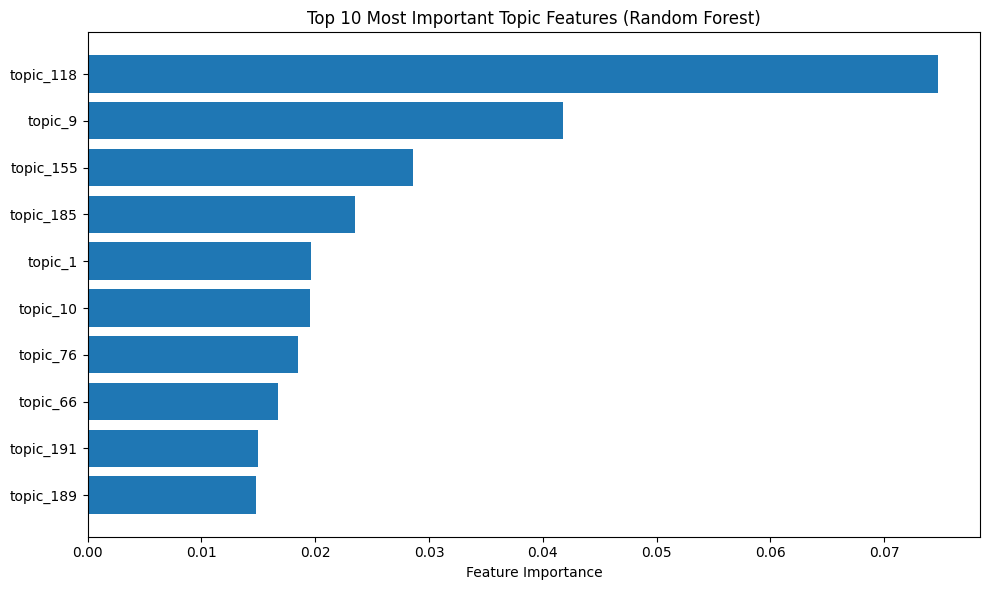

In [14]:
top_n = 10

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df['feature'].iloc[:top_n][::-1],
    feature_importance_df['importance'].iloc[:top_n][::-1]
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Most Important Topic Features (Random Forest)")
plt.tight_layout()
plt.show()

In [15]:
topic_model = BERTopic.load("../saved_models/topic_model_granular")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:

topic_info = topic_model.get_topic_info()

topic_number_to_name = dict(zip(topic_info['Topic'], topic_info['Name']))


In [17]:
def rename_topic_column(topic_col):
    if topic_col.startswith('topic_'):
        topic_num = int(topic_col.replace('topic_', ''))
        return topic_number_to_name.get(topic_num, topic_col)
    else:
        return topic_col

# SHAP

In [45]:
explainer = shap.TreeExplainer(best_model)

In [46]:
# X_sample = X_eval.sample(2000, random_state=42)
# X_sample = X_sample[topic_cols]
# X_sample = X_sample.rename(columns=lambda x: rename_topic_column(x))

X_all = pd.concat([X_eval, X_train], axis=0).reset_index(drop=True)
X_all = X_all.rename(columns=lambda x: rename_topic_column(x))


shap_values = explainer.shap_values(X_all, check_additivity=False)

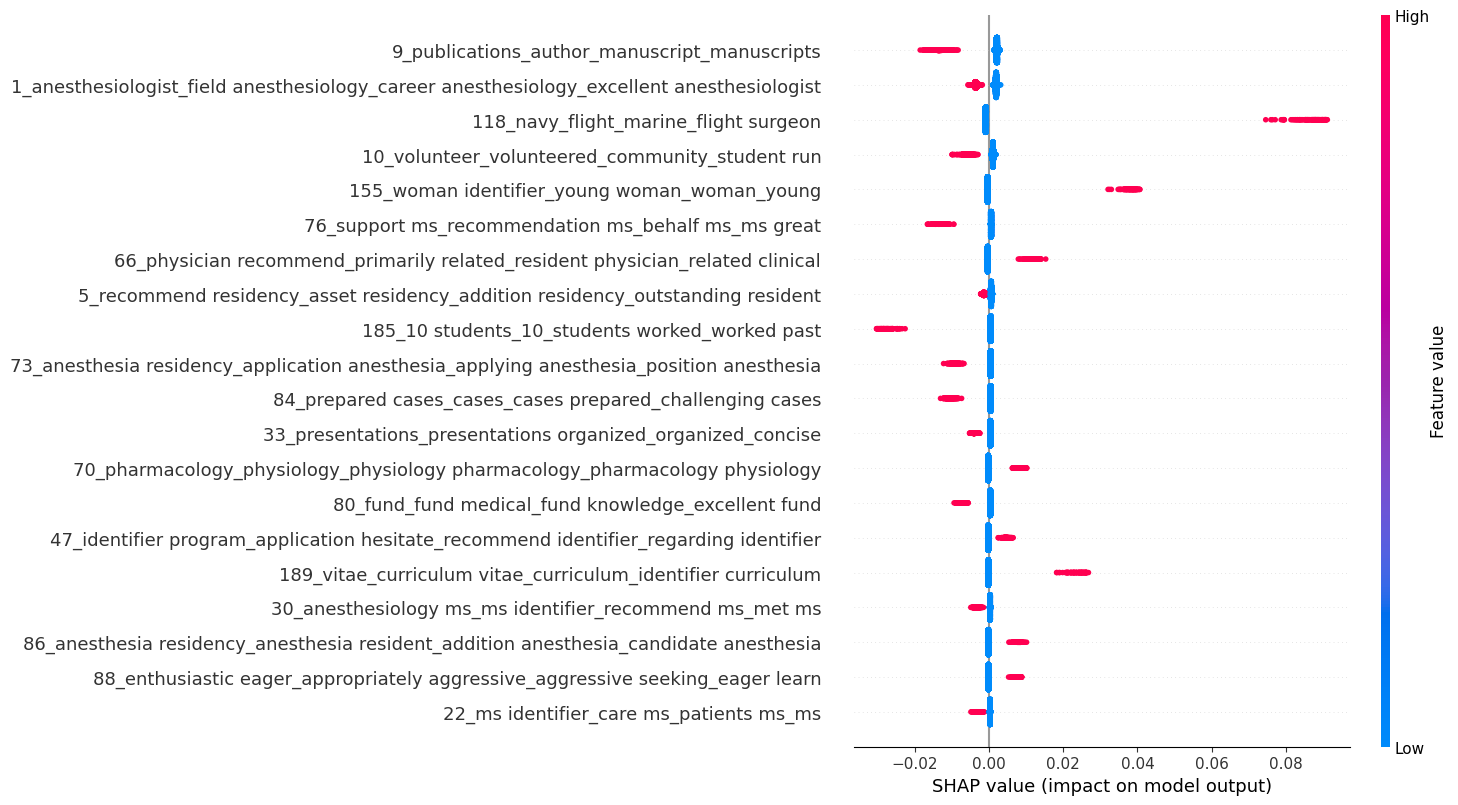

In [53]:
shap.summary_plot(shap_values[:, :, 1], X_all)